# Silver TradeEvent — Data Quality Exploration

Load TradeEvent parquet from S3, check reliability:
- Coverage: which dates have data? How many trades per day?
- Timestamps: are `t_receipt_ns` and `t_exchange_ns` monotonic? What's the latency?
- Fields: any nulls, out-of-range prices, zero sizes?
- Market tickers: distribution, naming patterns
- Trade flow: volume over time, side balance

In [32]:
import boto3
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

S3_BUCKET = "prediction-markets-data"
SILVER_PREFIX = "silver/kalshi_ws/TradeEvent/"
SILVER_VERSION = 3

s3 = boto3.client("s3")

In [33]:
# Discover all dates with TradeEvent silver data
paginator = s3.get_paginator("list_objects_v2")
dates = set()
for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=SILVER_PREFIX, Delimiter="/"):
    for cp in page.get("CommonPrefixes", []):
        # prefix looks like: silver/kalshi_ws/TradeEvent/date=2026-04-22/
        part = cp["Prefix"].split("date=")[-1].rstrip("/")
        dates.add(part)

dates = sorted(dates)
print(f"Found {len(dates)} dates with TradeEvent data")
print(f"Range: {dates[0]} → {dates[-1]}")
print(f"\nAll dates: {dates}")

Found 4 dates with TradeEvent data
Range: 2026-04-19 → 2026-05-03

All dates: ['2026-04-19', '2026-04-20', '2026-04-21', '2026-05-03']


In [34]:
# Load TradeEvent data from 2026-04-21 onward
def load_trade_events(dates: list[str]) -> pl.DataFrame:
    """Read all TradeEvent parquet files from S3."""
    frames = []
    for date in dates:
        prefix = f"{SILVER_PREFIX}date={date}/v={SILVER_VERSION}/"
        for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=prefix):
            for obj in page.get("Contents", []):
                key = obj["Key"]
                if not key.endswith(".parquet"):
                    continue
                resp = s3.get_object(Bucket=S3_BUCKET, Key=key)
                df = pl.read_parquet(resp["Body"].read())
                df = df.with_columns(pl.lit(date).alias("date"))
                frames.append(df)
    if not frames:
        return pl.DataFrame()
    return pl.concat(frames)

# Filter to dates >= 2026-04-21
dates = [d for d in dates if d >= "2026-04-21"]
print(f"Using {len(dates)} dates from 2026-04-21 onward: {dates}")

df = load_trade_events(dates)
print(f"\nTotal trades: {len(df):,}")
print(f"\nSchema:")
print(df.schema)
print(f"\nHead:")
df.head(10)

Using 2 dates from 2026-04-21 onward: ['2026-04-21', '2026-05-03']

Total trades: 433,069

Schema:
Schema({'t_receipt_ns': Int64, 't_exchange_ns': Int64, 'market_ticker': Categorical, 'side': Categorical, 'price': Int32, 'size': Int32, 'sid': Int32, 'seq': Int32, 'date': String})

Head:


t_receipt_ns,t_exchange_ns,market_ticker,side,price,size,sid,seq,date
i64,i64,cat,cat,i32,i32,i32,i32,str
1776729550139611136,1776729550000000000,"""KXNBAGAME-26APR20ATLNYK-NYK""","""yes""",69,13,5,74335,"""2026-04-21"""
1776729550261099264,1776729550000000000,"""KXNBASPREAD-26APR20TORCLE-TOR6""","""no""",3,2,5,74336,"""2026-04-21"""
1776729550335410176,1776729550000000000,"""KXNBAGAME-26APR20TORCLE-TOR""","""yes""",11,214,5,74337,"""2026-04-21"""
1776729550441821696,1776729550000000000,"""KXNBAGAME-26APR20TORCLE-TOR""","""yes""",11,81,5,74338,"""2026-04-21"""
1776729550455483904,1776729550000000000,"""KXNBAGAME-26APR20TORCLE-TOR""","""no""",10,20,5,74339,"""2026-04-21"""
1776729550472342016,1776729550000000000,"""KXNBASPREAD-26APR20TORCLE-CLE1…","""no""",47,24,5,74340,"""2026-04-21"""
1776729550601779456,1776729550000000000,"""KXNBAGAME-26APR20ATLNYK-ATL""","""yes""",33,14,5,74341,"""2026-04-21"""
1776729550691425280,1776729550000000000,"""KXNBASPREAD-26APR20TORCLE-CLE1…","""yes""",49,43,5,74342,"""2026-04-21"""
1776729550826343680,1776729550000000000,"""KXNBAGAME-26APR20TORCLE-TOR""","""no""",10,135,5,74343,"""2026-04-21"""


## Basic field checks

In [35]:
# Null counts per column
print("=== Null counts ===")
for col in df.columns:
    nulls = df[col].null_count()
    pct = nulls / len(df) * 100
    print(f"  {col:20s}: {nulls:>8,} nulls ({pct:.1f}%)")

print("\n=== Value ranges ===")
print(f"  price: {df['price'].min()} – {df['price'].max()} (should be 1–99 cents)")
print(f"  size:  {df['size'].min()} – {df['size'].max()}")
print(f"  side values: {df['side'].unique().to_list()}")

# Check for invalid prices
bad_prices = df.filter((pl.col("price") < 1) | (pl.col("price") > 99))
print(f"\n  Trades with price outside [1, 99]: {len(bad_prices):,}")

# Check for zero or negative sizes
bad_sizes = df.filter(pl.col("size") <= 0)
print(f"  Trades with size <= 0: {len(bad_sizes):,}")

=== Null counts ===
  t_receipt_ns        :        0 nulls (0.0%)
  t_exchange_ns       :        0 nulls (0.0%)
  market_ticker       :        0 nulls (0.0%)
  side                :        0 nulls (0.0%)
  price               :        0 nulls (0.0%)
  size                :        0 nulls (0.0%)
  sid                 :        0 nulls (0.0%)
  seq                 :        0 nulls (0.0%)
  date                :        0 nulls (0.0%)

=== Value ranges ===
  price: 1 – 99 (should be 1–99 cents)
  size:  0 – 229885
  side values: ['no', 'yes']

  Trades with price outside [1, 99]: 0
  Trades with size <= 0: 1,555


## Timestamp reliability

In [36]:
# Timestamp monotonicity check (within each date)
print("=== Timestamp monotonicity (per date) ===")
for date in dates:
    day = df.filter(pl.col("date") == date).sort("t_receipt_ns")
    diffs = day["t_receipt_ns"].diff().drop_nulls()
    backwards = (diffs < 0).sum()
    print(f"  {date}: {len(day):>6,} trades, {backwards} backwards t_receipt_ns")

# Latency: t_receipt_ns - t_exchange_ns
has_exchange = df.filter(pl.col("t_exchange_ns").is_not_null())
print(f"\n=== Exchange timestamp coverage: {len(has_exchange):,}/{len(df):,} "
      f"({len(has_exchange)/len(df)*100:.1f}%) ===")

if len(has_exchange) > 0:
    latency_ms = (
        (has_exchange["t_receipt_ns"] - has_exchange["t_exchange_ns"])
        .cast(pl.Float64) / 1e6
    )
    print(f"\n=== Latency (t_receipt - t_exchange) ===")
    print(f"  mean:   {latency_ms.mean():.1f} ms")
    print(f"  median: {latency_ms.median():.1f} ms")
    print(f"  p95:    {latency_ms.quantile(0.95):.1f} ms")
    print(f"  p99:    {latency_ms.quantile(0.99):.1f} ms")
    print(f"  min:    {latency_ms.min():.1f} ms")
    print(f"  max:    {latency_ms.max():.1f} ms")
    
    # Negative latency = clock issue
    neg_latency = (latency_ms < 0).sum()
    print(f"  negative latency (clock skew): {neg_latency:,}")

=== Timestamp monotonicity (per date) ===
  2026-04-21: 417,758 trades, 0 backwards t_receipt_ns
  2026-05-03: 15,311 trades, 0 backwards t_receipt_ns

=== Exchange timestamp coverage: 433,069/433,069 (100.0%) ===

=== Latency (t_receipt - t_exchange) ===
  mean:   537.1 ms
  median: 537.2 ms
  p95:    986.9 ms
  p99:    1029.8 ms
  min:    16.1 ms
  max:    3284.4 ms
  negative latency (clock skew): 0


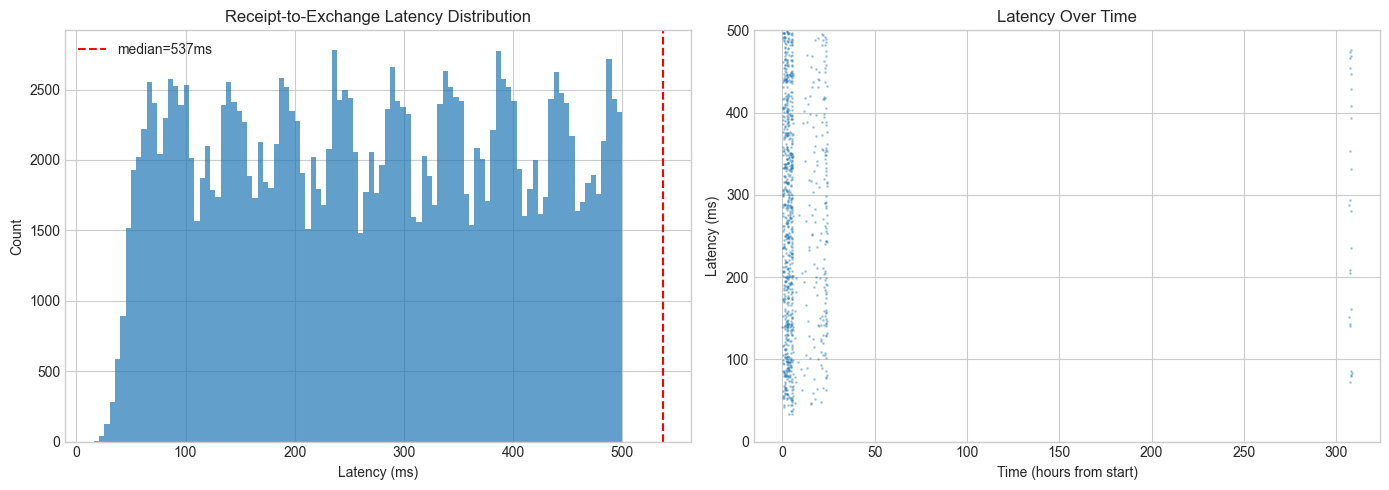

In [37]:
# Plot: latency distribution
if len(has_exchange) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram (clip to reasonable range for visibility)
    clipped = latency_ms.filter((latency_ms > 0) & (latency_ms < 500))
    axes[0].hist(clipped.to_numpy(), bins=100, edgecolor="none", alpha=0.7)
    axes[0].set_xlabel("Latency (ms)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Receipt-to-Exchange Latency Distribution")
    axes[0].axvline(latency_ms.median(), color="red", linestyle="--", label=f"median={latency_ms.median():.0f}ms")
    axes[0].legend()
    
    # Latency over time
    sample = has_exchange.sort("t_receipt_ns").gather_every(max(1, len(has_exchange) // 2000))
    t_hours = (sample["t_receipt_ns"] - sample["t_receipt_ns"].min()).cast(pl.Float64) / 3.6e12
    lat = (sample["t_receipt_ns"] - sample["t_exchange_ns"]).cast(pl.Float64) / 1e6
    axes[1].scatter(t_hours.to_numpy(), lat.to_numpy(), s=1, alpha=0.3)
    axes[1].set_xlabel("Time (hours from start)")
    axes[1].set_ylabel("Latency (ms)")
    axes[1].set_title("Latency Over Time")
    axes[1].set_ylim(0, min(500, lat.quantile(0.99) * 1.5))
    
    plt.tight_layout()
    plt.show()

## Trade volume by date

shape: (2, 4)
┌────────────┬──────────┬─────────────────┬───────────┐
│ date       ┆ n_trades ┆ total_contracts ┆ n_markets │
│ ---        ┆ ---      ┆ ---             ┆ ---       │
│ str        ┆ u32      ┆ i32             ┆ u32       │
╞════════════╪══════════╪═════════════════╪═══════════╡
│ 2026-04-21 ┆ 417758   ┆ 109212963       ┆ 552       │
│ 2026-05-03 ┆ 15311    ┆ 3357280         ┆ 167       │
└────────────┴──────────┴─────────────────┴───────────┘


/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/2157396535.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_trades"),


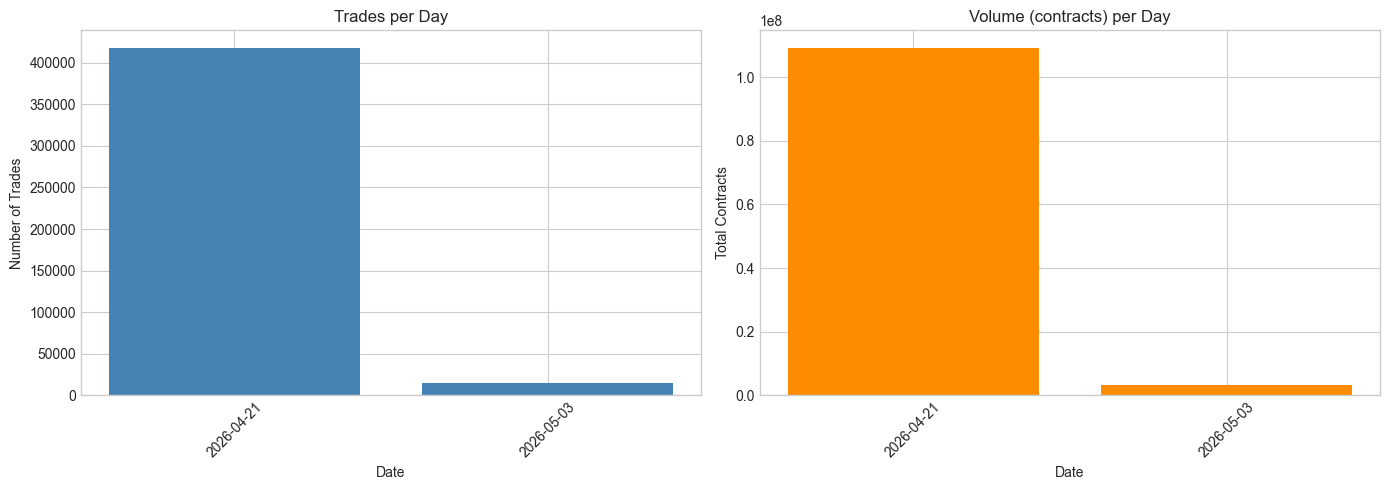

In [38]:
# Trades per date
daily = df.group_by("date").agg(
    pl.count().alias("n_trades"),
    pl.col("size").sum().alias("total_contracts"),
    pl.col("market_ticker").n_unique().alias("n_markets"),
)
daily = daily.sort("date")
print(daily)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(daily["date"].to_list(), daily["n_trades"].to_list(), color="steelblue")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Trades")
axes[0].set_title("Trades per Day")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(daily["date"].to_list(), daily["total_contracts"].to_list(), color="darkorange")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Contracts")
axes[1].set_title("Volume (contracts) per Day")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Market ticker analysis

In [39]:
# Top markets by trade count
market_stats = df.group_by("market_ticker").agg(
    pl.count().alias("n_trades"),
    pl.col("size").sum().alias("total_contracts"),
    pl.col("price").mean().alias("avg_price"),
).sort("n_trades", descending=True)

print(f"Total unique markets: {len(market_stats)}")
print(f"\nTop 20 markets by trade count:")
print(market_stats.head(20))

# Show a sample of ticker names to understand naming convention
print(f"\nSample tickers:")
for t in market_stats["market_ticker"].head(30).to_list():
    print(f"  {t}")

Total unique markets: 719

Top 20 markets by trade count:
shape: (20, 4)
┌─────────────────────────────────┬──────────┬─────────────────┬───────────┐
│ market_ticker                   ┆ n_trades ┆ total_contracts ┆ avg_price │
│ ---                             ┆ ---      ┆ ---             ┆ ---       │
│ cat                             ┆ u32      ┆ i32             ┆ f64       │
╞═════════════════════════════════╪══════════╪═════════════════╪═══════════╡
│ KXNBAGAME-26APR20MINDEN-MIN     ┆ 71576    ┆ 19025280        ┆ 35.903306 │
│ KXNBAGAME-26APR20MINDEN-DEN     ┆ 38079    ┆ 15015553        ┆ 54.806613 │
│ KXNBAGAME-26APR20ATLNYK-ATL     ┆ 34087    ┆ 10677527        ┆ 37.558776 │
│ KXNBAGAME-26APR20ATLNYK-NYK     ┆ 31706    ┆ 13239593        ┆ 55.311644 │
│ KXNBAGAME-26APR21PHIBOS-PHI     ┆ 20828    ┆ 5671828         ┆ 12.413434 │
│ …                               ┆ …        ┆ …               ┆ …         │
│ KXNBATOTAL-26APR20MINDEN-239    ┆ 4116     ┆ 769722          ┆ 46.413994 │
│ K

/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/3883755938.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_trades"),


## Price distribution and side balance

/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/1689368952.py:18: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  side_counts = df.group_by("side").agg(pl.count().alias("n"))


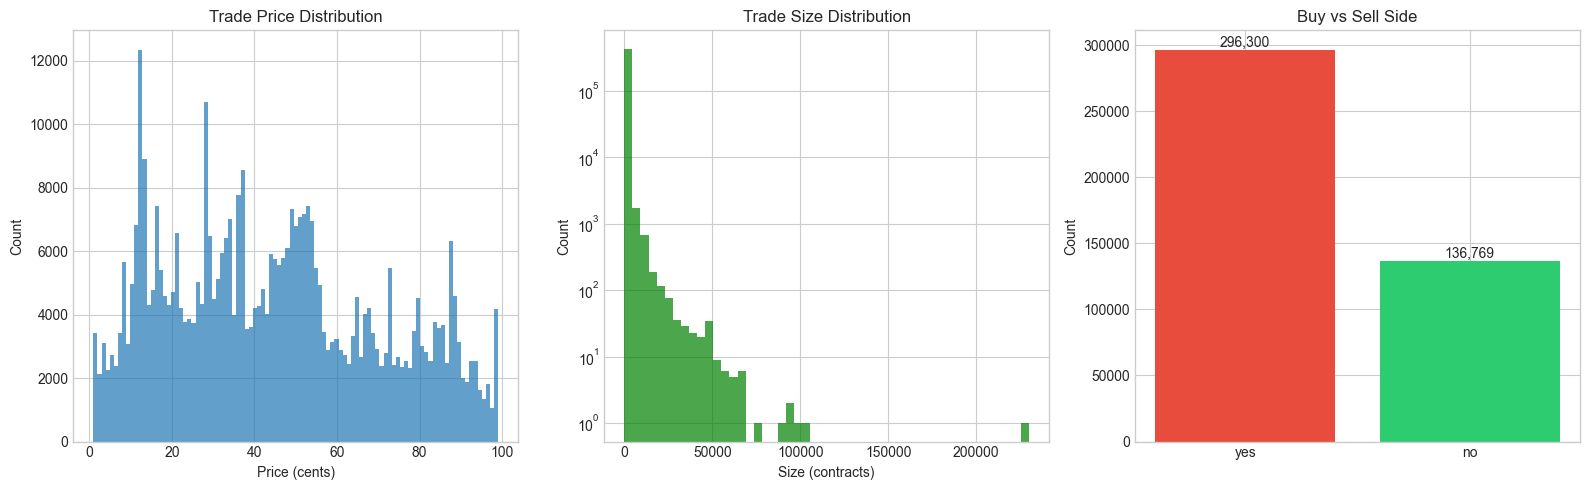


Side balance per date:
shape: (2, 3)
┌────────────┬────────┬────────┐
│ date       ┆ no     ┆ yes    │
│ ---        ┆ ---    ┆ ---    │
│ str        ┆ u32    ┆ u32    │
╞════════════╪════════╪════════╡
│ 2026-04-21 ┆ 129960 ┆ 287798 │
│ 2026-05-03 ┆ 6809   ┆ 8502   │
└────────────┴────────┴────────┘


/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/1689368952.py:29: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  side_daily = df.group_by(["date", "side"]).agg(pl.count().alias("n")).sort("date")


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Price distribution
axes[0].hist(df["price"].to_numpy(), bins=99, range=(1, 99), edgecolor="none", alpha=0.7)
axes[0].set_xlabel("Price (cents)")
axes[0].set_ylabel("Count")
axes[0].set_title("Trade Price Distribution")

# Size distribution (log scale)
sizes = df["size"].to_numpy()
axes[1].hist(sizes, bins=50, edgecolor="none", alpha=0.7, color="green")
axes[1].set_xlabel("Size (contracts)")
axes[1].set_ylabel("Count")
axes[1].set_title("Trade Size Distribution")
axes[1].set_yscale("log")

# Side balance
side_counts = df.group_by("side").agg(pl.count().alias("n"))
axes[2].bar(side_counts["side"].to_list(), side_counts["n"].to_list(), color=["#e74c3c", "#2ecc71"])
axes[2].set_ylabel("Count")
axes[2].set_title("Buy vs Sell Side")
for i, (side, n) in enumerate(zip(side_counts["side"].to_list(), side_counts["n"].to_list())):
    axes[2].text(i, n, f"{n:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Side balance per date
side_daily = df.group_by(["date", "side"]).agg(pl.count().alias("n")).sort("date")
print("\nSide balance per date:")
print(side_daily.pivot(on="side", index="date", values="n"))

## Sequence gaps (data completeness)

In [41]:
# Check sequence number gaps (per sid) — gaps mean we missed trades
has_seq = df.filter(pl.col("seq").is_not_null() & pl.col("sid").is_not_null())
print(f"Trades with sequence numbers: {len(has_seq):,}/{len(df):,}")

if len(has_seq) > 0:
    # Group by sid, sort by seq, find gaps
    gap_report = []
    for sid in has_seq["sid"].unique().sort().to_list():
        sid_df = has_seq.filter(pl.col("sid") == sid).sort("seq")
        seqs = sid_df["seq"].to_numpy()
        diffs = np.diff(seqs)
        gaps = diffs[diffs > 1]
        if len(gaps) > 0:
            gap_report.append({
                "sid": sid,
                "n_trades": len(sid_df),
                "n_gaps": len(gaps),
                "total_missing": int(gaps.sum() - len(gaps)),
                "max_gap": int(gaps.max()),
            })
    
    if gap_report:
        gap_df = pl.DataFrame(gap_report)
        print(f"\nSubscriptions with sequence gaps: {len(gap_df)}")
        print(gap_df)
        total_missing = gap_df["total_missing"].sum()
        print(f"\nTotal estimated missing trades: {total_missing:,}")
    else:
        print("\nNo sequence gaps detected — data appears complete!")

Trades with sequence numbers: 433,069/433,069

No sequence gaps detected — data appears complete!


## Intraday trade timing

/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/2616238779.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_trades"),


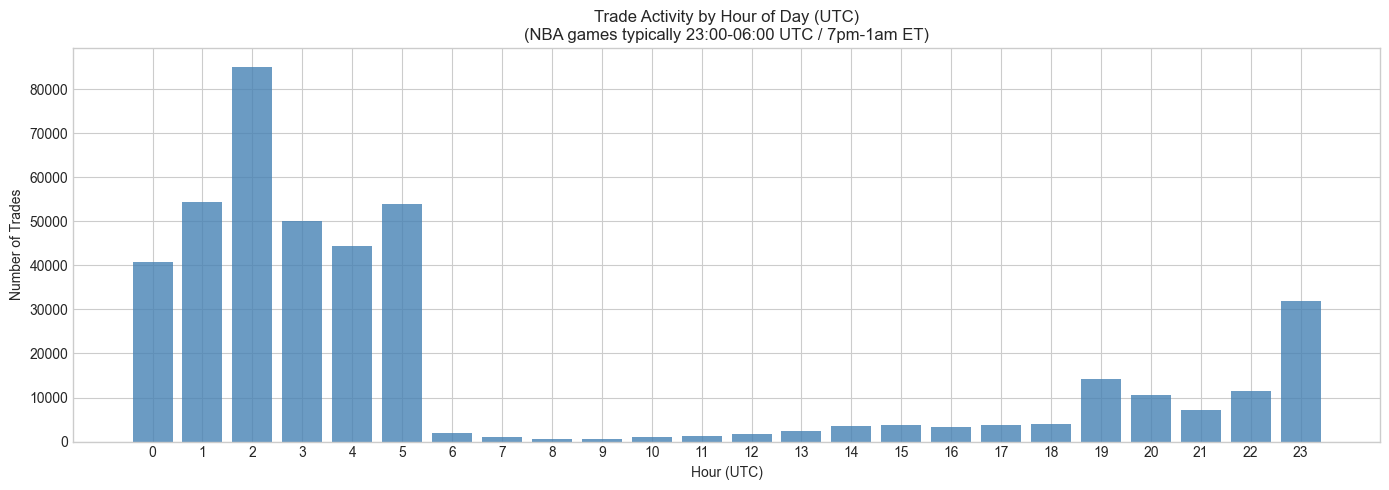

In [42]:
# Convert t_receipt_ns to hour of day (UTC)
df_time = df.with_columns(
    (pl.col("t_receipt_ns") // 1_000_000_000).cast(pl.Int64).alias("epoch_s")
).with_columns(
    (pl.col("epoch_s") % 86400 // 3600).alias("hour_utc")
)

hourly = df_time.group_by("hour_utc").agg(
    pl.count().alias("n_trades"),
    pl.col("size").sum().alias("total_volume"),
).sort("hour_utc")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hourly["hour_utc"].to_list(), hourly["n_trades"].to_list(), color="steelblue", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of Trades")
ax.set_title("Trade Activity by Hour of Day (UTC)\n(NBA games typically 23:00-06:00 UTC / 7pm-1am ET)")
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## Duplicate detection

In [43]:
# Check for exact duplicate rows (same timestamp + ticker + price + size + side)
dedup_cols = ["t_receipt_ns", "market_ticker", "price", "size", "side"]
n_before = len(df)
n_after = df.unique(subset=dedup_cols).height
dupes = n_before - n_after
print(f"Exact duplicates (same t_receipt_ns + ticker + price + size + side): {dupes:,}")
print(f"  ({dupes/n_before*100:.2f}% of total)")

# Check for trades with identical t_exchange_ns (batch fills from same aggressor order)
if len(has_exchange) > 0:
    same_ts = has_exchange.group_by(["t_exchange_ns", "market_ticker"]).agg(
        pl.count().alias("n")
    ).filter(pl.col("n") > 1)
    print(f"\nBatch fills (same t_exchange_ns + ticker, multiple trades): {len(same_ts):,} groups")
    if len(same_ts) > 0:
        print(f"  Max trades in one batch: {same_ts['n'].max()}")
        print(f"  Mean trades per batch: {same_ts['n'].mean():.1f}")

Exact duplicates (same t_receipt_ns + ticker + price + size + side): 0
  (0.00% of total)

Batch fills (same t_exchange_ns + ticker, multiple trades): 71,275 groups
  Max trades in one batch: 111
  Mean trades per batch: 4.3


/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/3892980899.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n")


## Summary

In [44]:
print("=" * 60)
print("DATA RELIABILITY SUMMARY")
print("=" * 60)
print(f"  Date range:        {dates[0]} → {dates[-1]} ({len(dates)} days)")
print(f"  Total trades:      {len(df):,}")
print(f"  Unique markets:    {df['market_ticker'].n_unique()}")
print(f"  Price range:       {df['price'].min()} – {df['price'].max()} cents")
print(f"  Invalid prices:    {len(bad_prices):,}")
print(f"  Invalid sizes:     {len(bad_sizes):,}")
print(f"  Exact duplicates:  {dupes:,}")
print(f"  Exchange ts cover: {len(has_exchange)/len(df)*100:.1f}%")
print(f"  Seq number cover:  {len(has_seq)/len(df)*100:.1f}%")
print("=" * 60)

DATA RELIABILITY SUMMARY
  Date range:        2026-04-21 → 2026-05-03 (2 days)
  Total trades:      433,069
  Unique markets:    719
  Price range:       1 – 99 cents
  Invalid prices:    0
  Invalid sizes:     1,555
  Exact duplicates:  0
  Exchange ts cover: 100.0%
  Seq number cover:  100.0%


## Single market deep-dive: price over time

Resolved markets: 161
shape: (10, 3)
┌────────────────────────────────┬────────────┬──────────┐
│ market_ticker                  ┆ last_price ┆ n_trades │
│ ---                            ┆ ---        ┆ ---      │
│ cat                            ┆ i32        ┆ u32      │
╞════════════════════════════════╪════════════╪══════════╡
│ KXNBAGAME-26APR20MINDEN-MIN    ┆ 99         ┆ 71576    │
│ KXNBAGAME-26APR20MINDEN-DEN    ┆ 1          ┆ 38079    │
│ KXNBAGAME-26APR20ATLNYK-ATL    ┆ 99         ┆ 34087    │
│ KXNBAGAME-26APR20ATLNYK-NYK    ┆ 1          ┆ 31706    │
│ KXNBAGAME-26APR20TORCLE-TOR    ┆ 1          ┆ 9726     │
│ KXNBASPREAD-26APR20MINDEN-DEN7 ┆ 1          ┆ 8752     │
│ KXNBASPREAD-26APR20MINDEN-DEN4 ┆ 1          ┆ 6702     │
│ KXNBASPREAD-26APR20ATLNYK-NYK7 ┆ 1          ┆ 5814     │
│ KXNBATOTAL-26APR20MINDEN-233   ┆ 1          ┆ 5731     │
│ KXNBASPREAD-26APR20TORCLE-CLE9 ┆ 99         ┆ 4783     │
└────────────────────────────────┴────────────┴──────────┘

Market: KXNBAGAME-

/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_39269/630226977.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_trades"),


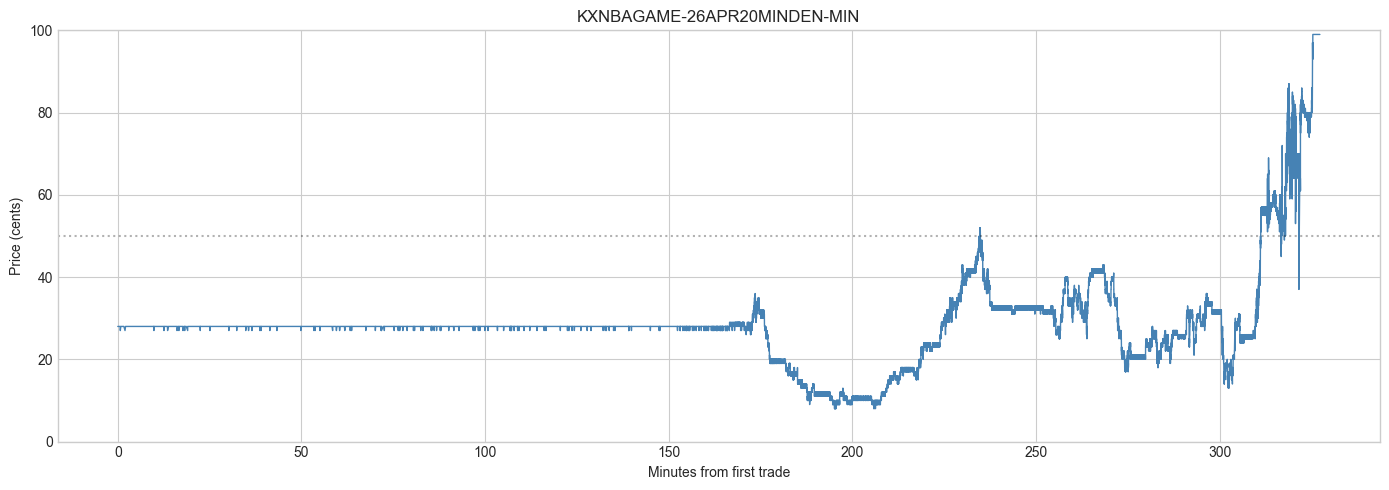

In [46]:
# Pick a market that resolved (price ended at 1 or 99 cents = settled)
resolved = df.group_by("market_ticker").agg(
    pl.col("price").last().alias("last_price"),
    pl.count().alias("n_trades"),
).filter(
    ((pl.col("last_price") <= 5) | (pl.col("last_price") >= 95))
).sort("n_trades", descending=True)

print(f"Resolved markets: {len(resolved)}")
print(resolved.head(10))

# Pick the most-traded resolved market
random_ticker = resolved["market_ticker"][0]

ticker_df = df.filter(pl.col("market_ticker") == random_ticker).sort("t_receipt_ns")
print(f"\nMarket: {random_ticker}")
print(f"Trades: {len(ticker_df):,}")
print(f"Final price: {ticker_df['price'][-1]} cents")

# Convert to minutes from first trade
t0 = ticker_df["t_receipt_ns"][0]
minutes = (ticker_df["t_receipt_ns"] - t0).cast(pl.Float64) / 6e10

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(minutes.to_numpy(), ticker_df["price"].to_numpy(), linewidth=1, color="steelblue")
ax.set_xlabel("Minutes from first trade")
ax.set_ylabel("Price (cents)")
ax.set_title(f"{random_ticker}")
ax.set_ylim(0, 100)
ax.axhline(50, color="black", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

## Overlay: Trade price + NBA game score differential

In [47]:
import gzip

# Step 1: Show the ticker we're plotting so we can identify the game
print(f"Market ticker: {random_ticker}")
print(f"Date of trades: {ticker_df['date'][0]}")
print(f"First trade t_receipt_ns: {ticker_df['t_receipt_ns'][0]}")
print(f"Last trade t_receipt_ns: {ticker_df['t_receipt_ns'][-1]}")

# Convert to epoch seconds for matching
t_start = ticker_df["t_receipt_ns"][0] / 1e9
t_end = ticker_df["t_receipt_ns"][-1] / 1e9
from datetime import datetime, timezone
print(f"Time range: {datetime.fromtimestamp(t_start, tz=timezone.utc)} → {datetime.fromtimestamp(t_end, tz=timezone.utc)}")

Market ticker: KXNBAGAME-26APR20MINDEN-MIN
Date of trades: 2026-04-21
First trade t_receipt_ns: 1776729552063741184
Last trade t_receipt_ns: 1776749187337801728
Time range: 2026-04-20 23:59:12.063741+00:00 → 2026-04-21 05:26:27.337802+00:00


In [48]:
# Step 2: Load all boxscore snapshots that overlap with the trade time window
# We'll check the date folder(s) that correspond to the trade times
from datetime import timedelta

trade_date = ticker_df["date"][0]  # e.g. "2026-04-21"
y, m, d = trade_date.split("-")

# Load boxscore records from that date (and possibly day before if game started prev day)
def load_boxscores(date_prefix: str) -> list[dict]:
    """Load all boxscore records from a date prefix."""
    records = []
    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=date_prefix):
        for obj in page.get("Contents", []):
            if not obj["Key"].endswith(".jsonl.gz"):
                continue
            resp = s3.get_object(Bucket=S3_BUCKET, Key=obj["Key"])
            data = gzip.decompress(resp["Body"].read()).decode()
            for line in data.strip().split("\n"):
                if line.strip():
                    records.append(json.loads(line))
    return records

# Load from the trade date and possibly day before
import json
box_records = []
for offset in [0, -1]:
    dt = datetime.strptime(trade_date, "%Y-%m-%d") + timedelta(days=offset)
    prefix = f"bronze/nba_cdn/boxscore/{dt.strftime('%Y/%m/%d')}/"
    recs = load_boxscores(prefix)
    box_records.extend(recs)
    print(f"  {prefix}: {len(recs)} snapshots")

print(f"\nTotal boxscore snapshots loaded: {len(box_records)}")

# Find which game_ids overlap with our trade time window (within 1hr buffer)
game_ids_in_window = set()
for rec in box_records:
    t = rec.get("t_receipt", 0)
    if t_start - 3600 < t < t_end + 3600:
        gid = rec.get("game_id")
        game_code = rec.get("frame", {}).get("game", {}).get("gameCode", "")
        if gid not in game_ids_in_window:
            game_ids_in_window.add(gid)
            print(f"  Game in window: {gid} — {game_code}")

print(f"\nGames overlapping trade window: {game_ids_in_window}")

  bronze/nba_cdn/boxscore/2026/04/21/: 5434 snapshots
  bronze/nba_cdn/boxscore/2026/04/20/: 4570 snapshots

Total boxscore snapshots loaded: 10004
  Game in window: 0042500132 — 20260420/TORCLE
  Game in window: 0042500122 — 20260420/ATLNYK
  Game in window: 0042500162 — 20260420/MINDEN

Games overlapping trade window: {'0042500132', '0042500162', '0042500122'}


In [49]:
# Step 3: Pick the game that best matches the ticker (manual pick if multiple)
# Try to match game_code teams to the ticker string
# e.g. ticker "KXNBA-26APR21-NYK-..." should match gameCode "20260421/PHIBOS"

print(f"Ticker: {random_ticker}")
print(f"Games found: {game_ids_in_window}")

# Try to auto-match by finding team codes in the ticker
best_game_id = None
for rec in box_records:
    if rec.get("game_id") not in game_ids_in_window:
        continue
    game = rec.get("frame", {}).get("game", {})
    home = game.get("homeTeam", {}).get("teamTricode", "")
    away = game.get("awayTeam", {}).get("teamTricode", "")
    ticker_upper = random_ticker.upper()
    if home in ticker_upper or away in ticker_upper:
        best_game_id = rec["game_id"]
        print(f"\nMatched: {best_game_id} ({away}@{home})")
        break

# If no auto-match, just use the first game
if not best_game_id and game_ids_in_window:
    best_game_id = list(game_ids_in_window)[0]
    print(f"\nNo ticker match — using first game: {best_game_id}")

# Extract time series: t_receipt, home_score, away_score, period, game_clock
game_snapshots = []
seen_t = set()
for rec in box_records:
    if rec.get("game_id") != best_game_id:
        continue
    t = rec.get("t_receipt", 0)
    if t in seen_t:
        continue
    seen_t.add(t)
    game = rec.get("frame", {}).get("game", {})
    game_snapshots.append({
        "t_receipt": t,
        "home_score": game.get("homeTeam", {}).get("score", 0),
        "away_score": game.get("awayTeam", {}).get("score", 0),
        "period": game.get("period", 0),
        "game_clock": game.get("gameClock", ""),
        "home_team": game.get("homeTeam", {}).get("teamTricode", ""),
        "away_team": game.get("awayTeam", {}).get("teamTricode", ""),
    })

game_snapshots.sort(key=lambda x: x["t_receipt"])
game_df = pl.DataFrame(game_snapshots)
game_df = game_df.with_columns(
    (pl.col("home_score") - pl.col("away_score")).alias("score_diff")
)
print(f"\nGame snapshots: {len(game_df)}")
print(f"Teams: {game_df['away_team'][0]} @ {game_df['home_team'][0]}")
print(f"Final: {game_df['home_score'][-1]}-{game_df['away_score'][-1]}")
print(game_df.head(5))

Ticker: KXNBAGAME-26APR20MINDEN-MIN
Games found: {'0042500132', '0042500162', '0042500122'}

Matched: 0042500162 (MIN@DEN)

Game snapshots: 1855
Teams: MIN @ DEN
Final: 114-119
shape: (5, 8)
┌───────────┬────────────┬────────────┬────────┬─────────────┬───────────┬───────────┬────────────┐
│ t_receipt ┆ home_score ┆ away_score ┆ period ┆ game_clock  ┆ home_team ┆ away_team ┆ score_diff │
│ ---       ┆ ---        ┆ ---        ┆ ---    ┆ ---         ┆ ---       ┆ ---       ┆ ---        │
│ f64       ┆ i64        ┆ i64        ┆ i64    ┆ str         ┆ str       ┆ str       ┆ i64        │
╞═══════════╪════════════╪════════════╪════════╪═════════════╪═══════════╪═══════════╪════════════╡
│ 1.7767e9  ┆ 3          ┆ 3          ┆ 1      ┆ PT11M07.00S ┆ DEN       ┆ MIN       ┆ 0          │
│ 1.7767e9  ┆ 3          ┆ 3          ┆ 1      ┆ PT11M05.00S ┆ DEN       ┆ MIN       ┆ 0          │
│ 1.7767e9  ┆ 3          ┆ 3          ┆ 1      ┆ PT11M05.00S ┆ DEN       ┆ MIN       ┆ 0          │
│ 1.7767e

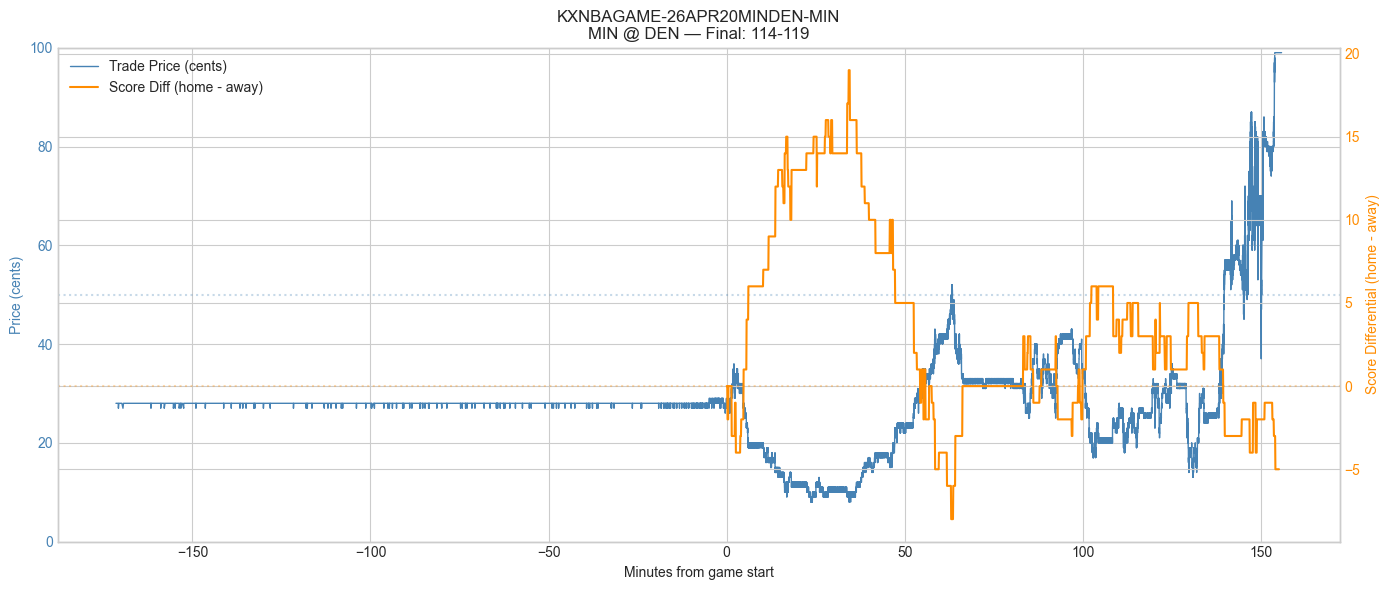

In [50]:
# Step 4: Overlay plot — trade price + score differential on same time axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Use absolute epoch time (seconds) as x-axis, then label as minutes from game start
game_t0 = game_df["t_receipt"][0]  # use game start as reference

# Trade price (left y-axis)
trade_minutes = (ticker_df["t_receipt_ns"].cast(pl.Float64) / 1e9 - game_t0) / 60
ax1.plot(trade_minutes.to_numpy(), ticker_df["price"].to_numpy(), 
         linewidth=1, color="steelblue", label="Trade Price (cents)")
ax1.set_xlabel("Minutes from game start")
ax1.set_ylabel("Price (cents)", color="steelblue")
ax1.set_ylim(0, 100)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axhline(50, color="steelblue", linestyle=":", alpha=0.3)

# Score differential (right y-axis)
ax2 = ax1.twinx()
score_minutes = (game_df["t_receipt"].cast(pl.Float64) - game_t0) / 60
ax2.plot(score_minutes.to_numpy(), game_df["score_diff"].to_numpy(),
         linewidth=1.5, color="darkorange", label="Score Diff (home - away)")
ax2.axhline(0, color="darkorange", linestyle=":", alpha=0.3)
ax2.set_ylabel("Score Differential (home - away)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Title
home = game_df["home_team"][0]
away = game_df["away_team"][0]
final_home = game_df["home_score"][-1]
final_away = game_df["away_score"][-1]
ax1.set_title(f"{random_ticker}\n{away} @ {home} — Final: {final_home}-{final_away}")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()